# Stratégie Hybride — XGBoost + SARIMA
## Système d'aide à la décision — Bénin Pétro SA

Ce notebook combine les deux approches de modélisation pour produire :
- les **commandes recommandées** du mois suivant (XGBoost — toutes stations)
- les **projections 12 mois** avec intervalles de confiance (SARIMA — stations stables)
- les **alertes de rupture de stock** pour le dashboard Power BI

**Prérequis :** avoir exécuté dans l'ordre :
1. `FE_Mensuel_v2.ipynb` → `dataset_ml_mensuel.csv`
2. `03_RF_Mensuel_v2.ipynb` → `random_forest_mensuel.pkl`
3. `04_XGBoost_Mensuel_v2.ipynb` → `xgboost_mensuel.pkl`

## 1. Imports et chargement des modèles

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_percentage_error

pd.set_option('display.max_columns', None)
print("Imports OK")


Imports OK


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CHARGEMENT DU DATASET ET DU MODÈLE XGBOOST
# ══════════════════════════════════════════════════════════════════════════════

# Dataset mensuel
df_ml = pd.read_csv("../data/propre/dataset_ml_mensuel.csv",
                    parse_dates=['mois'])

# Modèle XGBoost entraîné
xgb_model = joblib.load('xgboost_mensuel.pkl')

print(f"Dataset chargé   : {df_ml.shape[0]:,} lignes")
print(f"Période          : {df_ml['mois'].min().date()} → {df_ml['mois'].max().date()}")
print(f"Stations         : {df_ml['Code Station'].nunique()}")
print(f"Modèle XGBoost   : chargé ✅")


Dataset chargé   : 5,473 lignes
Période          : 2021-01-01 → 2025-12-01
Stations         : 89
Modèle XGBoost   : chargé ✅


## 2. Segmentation des stations

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SEGMENTATION PAR COEFFICIENT DE VARIATION
# cv < 0.30  → Segment A : stable     → XGBoost + SARIMA dédié
# cv 0.30-0.55 → Segment B : modéré   → XGBoost seul
# cv > 0.55  → Segment C : erratique  → Règle métier + alerte manuelle
# ══════════════════════════════════════════════════════════════════════════════

volatilite = (
    df_ml.groupby(['Code Station', 'N° article'])['quantite_mois']
    .agg(
        vol_moy = 'mean',
        vol_std = 'std',
        n_mois  = 'count'
    )
    .reset_index()
)
volatilite['cv'] = (volatilite['vol_std'] / volatilite['vol_moy']).round(3)

def segment(row):
    if row['cv'] < 0.30:
        return 'A — Stable'
    elif row['cv'] < 0.55:
        return 'B — Modéré'
    else:
        return 'C — Erratique'

volatilite['segment'] = volatilite.apply(segment, axis=1)

print("Distribution des segments :")
print(volatilite['segment'].value_counts().to_string())
print()
print(f"Segment A (SARIMA + XGBoost) : "
      f"{(volatilite['segment']=='A — Stable').sum()} couples station-produit")
print(f"Segment B (XGBoost seul)     : "
      f"{(volatilite['segment']=='B — Modéré').sum()} couples station-produit")
print(f"Segment C (alerte manuelle)  : "
      f"{(volatilite['segment']=='C — Erratique').sum()} couples station-produit")


Distribution des segments :
segment
B — Modéré       87
C — Erratique    49
A — Stable       35

Segment A (SARIMA + XGBoost) : 35 couples station-produit
Segment B (XGBoost seul)     : 87 couples station-produit
Segment C (alerte manuelle)  : 49 couples station-produit


## 3. Prévisions XGBoost — mois suivant (toutes stations)

XGBoost prédit la demande du **mois suivant** pour chaque station et produit.
C'est la base des commandes opérationnelles.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURES — identiques au notebook XGBoost mensuel
# ══════════════════════════════════════════════════════════════════════════════

FEATURES = [
    'StationEncoded', 'ProduitEncoded',
    'annee', 'num_mois', 'trimestre', 'mois_sin', 'mois_cos', 'saison_benin',
    'Lag_1', 'Lag_3', 'Lag_12',
    'Rolling_3m', 'Rolling_6m', 'Rolling_12m', 'Rolling_Std_3m',
    'ratio_tendance', 'nb_commandes',
]
TARGET = 'quantite_mois'


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PRÉVISIONS XGBOOST — MOIS SUIVANT
# On prend la dernière observation de chaque station comme point de départ
# ══════════════════════════════════════════════════════════════════════════════

derniere_obs = (
    df_ml.sort_values('mois')
    .groupby(['Code Station', 'N° article'])
    .last()
    .reset_index()
)

X_futur       = derniere_obs[FEATURES]
previsions_xgb = np.maximum(xgb_model.predict(X_futur), 0)

df_commandes = derniere_obs[['Code Station', 'N° article', 'mois']].copy()
df_commandes.rename(columns={'mois': 'Dernier_mois_connu'}, inplace=True)
df_commandes['Prevision_mois_suivant_L'] = previsions_xgb.round(0).astype(int)

# Ajouter le segment et la volatilité
df_commandes = df_commandes.merge(
    volatilite[['Code Station', 'N° article', 'segment', 'cv', 'vol_moy']],
    on=['Code Station', 'N° article']
)

# Stock de sécurité recommandé selon le segment
def stock_securite(row):
    if row['segment'] == 'A — Stable':
        return round(row['Prevision_mois_suivant_L'] * 0.15)  # 15%
    elif row['segment'] == 'B — Modéré':
        return round(row['Prevision_mois_suivant_L'] * 0.25)  # 25%
    else:
        return round(row['Prevision_mois_suivant_L'] * 0.40)  # 40%

df_commandes['Stock_securite_L'] = df_commandes.apply(stock_securite, axis=1)
df_commandes['Commande_totale_L'] = (
    df_commandes['Prevision_mois_suivant_L'] +
    df_commandes['Stock_securite_L']
)

print("=== COMMANDES RECOMMANDÉES — MOIS SUIVANT ===")
print(df_commandes[['Code Station', 'N° article',
                     'Prevision_mois_suivant_L', 'Stock_securite_L',
                     'Commande_totale_L', 'segment']]
      .sort_values('Commande_totale_L', ascending=False)
      .to_string(index=False))


=== COMMANDES RECOMMANDÉES — MOIS SUIVANT ===
Code Station N° article  Prevision_mois_suivant_L  Stock_securite_L  Commande_totale_L       segment
      ST0002      A0001                    164882             41220             206102    B — Modéré
      ST0084      A0001                    128002             19200             147202    A — Stable
      ST0001      A0001                    104352             15653             120005    A — Stable
      ST0066      A0002                     89449             13417             102866    A — Stable
      ST0066      A0001                     88627             13294             101921    A — Stable
      ST0074      A0002                     77881             19470              97351    B — Modéré
      ST0039      A0001                     74836             11225              86061    A — Stable
      ST0054      A0001                     71824             10774              82598    A — Stable
      ST0073      A0001                     6

## 4. Projections SARIMA 12 mois — stations stables

SARIMA est entraîné **uniquement sur les stations du Segment A** (cv < 0.30).
Il produit une projection annuelle avec intervalles de confiance
pour la planification budgétaire de la direction.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# PROJECTIONS SARIMA 12 MOIS — SEGMENT A UNIQUEMENT
# ══════════════════════════════════════════════════════════════════════════════

stations_stables = volatilite[volatilite['segment'] == 'A — Stable']
resultats_sarima = []

print(f"Traitement de {len(stations_stables)} couples station-produit stables...")
print()

for _, row in stations_stables.iterrows():
    station = row['Code Station']
    article = row['N° article']

    # Extraire la série mensuelle complète
    serie = (
        df_ml[
            (df_ml['Code Station'] == station) &
            (df_ml['N° article']   == article)
        ]
        .sort_values('mois')
        .set_index('mois')['quantite_mois']
    )

    # Minimum 24 mois pour SARIMA
    if len(serie) < 24:
        print(f"  ⚠️  {station}/{article} : historique trop court ({len(serie)} mois)")
        continue

    try:
        # Sélection automatique des paramètres SARIMA
        model_auto = auto_arima(
            serie, seasonal=True, m=12,
            start_p=0, max_p=2,
            start_q=0, max_q=2,
            trace=False, error_action='ignore',
            suppress_warnings=True, stepwise=True
        )

        # Entraînement sur toute la série
        sarima_fit = SARIMAX(
            serie,
            order=model_auto.order,
            seasonal_order=model_auto.seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        # Prévisions 12 mois avec IC 95%
        forecast   = sarima_fit.get_forecast(steps=12)
        pred_mean  = np.maximum(forecast.predicted_mean, 0)
        conf_int   = forecast.conf_int()

        for h in range(12):
            resultats_sarima.append({
                'Code Station'  : station,
                'N° article'    : article,
                'Horizon_mois'  : h + 1,
                'Prevision_L'   : round(pred_mean.iloc[h]),
                'IC_bas_L'      : round(max(0, conf_int.iloc[h, 0])),
                'IC_haut_L'     : round(conf_int.iloc[h, 1]),
                'Ordre_SARIMA'  : str(model_auto.order) + str(model_auto.seasonal_order),
            })

        print(f"  ✅ {station}/{article} : "
              f"SARIMA{model_auto.order}{model_auto.seasonal_order}")

    except Exception as e:
        print(f"  ❌ {station}/{article} : {e}")
        continue

df_sarima = pd.DataFrame(resultats_sarima)
print(f"\nProjections SARIMA générées : {len(df_sarima)} lignes")


Traitement de 35 couples station-produit stables...



C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ST0001/A0001 : SARIMA(0, 0, 0)(0, 0, 0, 12)
  ⚠️  ST0005/A0001 : historique trop court (3 mois)


C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ST0006/A0001 : SARIMA(1, 0, 0)(0, 0, 2, 12)


...

C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ST0067/A0001 : SARIMA(1, 0, 0)(0, 0, 0, 12)
  ⚠️  ST0070/A0001 : historique trop court (8 mois)
  ⚠️  ST0070/A0002 : historique trop court (8 mois)
  ⚠️  ST0072/A0001 : historique trop court (16 mois)
  ⚠️  ST0077/A0001 : historique trop court (3 mois)
  ⚠️  ST0082/A0001 : historique trop court (11 mois)
  ⚠️  ST0082/A0002 : historique trop court (10 mois)


C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  ✅ ST0084/A0001 : SARIMA(0, 1, 0)(0, 0, 0, 12)
  ✅ ST0084/A0002 : SARIMA(1, 0, 0)(0, 0, 0, 12)
  ⚠️  ST0089/A0001 : historique trop court (4 mois)
  ⚠️  ST0095/A0001 : historique trop court (4 mois)

Projections SARIMA générées : 132 lignes


C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\gganye\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 5. Alertes de rupture de stock

C'est le cœur du système d'aide à la décision.
Chaque station reçoit un **niveau d'alerte** basé sur la comparaison
entre le stock actuel estimé et le seuil de commande.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CALCUL DES ALERTES DE RUPTURE
#
# Logique :
#   Stock actuel estimé = dernière quantité commandée (proxy)
#   Seuil critique      = stock_securite_L (15/25/40% selon segment)
#   Seuil attention     = seuil_critique × 1.5
#
# Niveaux :
#   🔴 CRITIQUE  : stock estimé < seuil critique   → commander immédiatement
#   🟠 ATTENTION : stock estimé < seuil attention  → préparer la commande
#   🟢 OK        : stock suffisant
# ══════════════════════════════════════════════════════════════════════════════

# Proxy du stock actuel = dernière quantité livrée connue
df_commandes['Stock_actuel_estime_L'] = (
    df_ml.sort_values('mois')
    .groupby(['Code Station', 'N° article'])['quantite_mois']
    .last()
    .reset_index()
    .rename(columns={'quantite_mois': 'Stock_actuel_estime_L'})
    .merge(df_commandes[['Code Station', 'N° article']], on=['Code Station', 'N° article'])
    ['Stock_actuel_estime_L']
    .values
)

df_commandes['Seuil_critique_L']  = df_commandes['Stock_securite_L']
df_commandes['Seuil_attention_L'] = (df_commandes['Stock_securite_L'] * 1.5).round(0).astype(int)

def niveau_alerte(row):
    stock  = row['Stock_actuel_estime_L']
    crit   = row['Seuil_critique_L']
    att    = row['Seuil_attention_L']
    if stock <= crit:
        return 'CRITIQUE'
    elif stock <= att:
        return 'ATTENTION'
    else:
        return 'OK'

def priorite(row):
    if row['Niveau_alerte'] == 'CRITIQUE':  return 1
    elif row['Niveau_alerte'] == 'ATTENTION': return 2
    else: return 3

df_commandes['Niveau_alerte'] = df_commandes.apply(niveau_alerte, axis=1)
df_commandes['Priorite']      = df_commandes.apply(priorite, axis=1)

# Résumé des alertes
print("=== RÉSUMÉ DES ALERTES ===")
print(df_commandes['Niveau_alerte'].value_counts().to_string())
print()

# Stations en alerte critique
critique = df_commandes[df_commandes['Niveau_alerte'] == 'CRITIQUE']
print(f"🔴 STATIONS EN ALERTE CRITIQUE ({len(critique)}) :")
if len(critique) > 0:
    print(critique[['Code Station', 'N° article',
                     'Stock_actuel_estime_L', 'Seuil_critique_L',
                     'Commande_totale_L', 'segment']]
          .sort_values('Commande_totale_L', ascending=False)
          .to_string(index=False))
print()

# Stations en attention
attention = df_commandes[df_commandes['Niveau_alerte'] == 'ATTENTION']
print(f"🟠 STATIONS EN ATTENTION ({len(attention)}) :")
if len(attention) > 0:
    print(attention[['Code Station', 'N° article',
                      'Stock_actuel_estime_L', 'Seuil_attention_L',
                      'Commande_totale_L', 'segment']]
          .sort_values('Commande_totale_L', ascending=False)
          .to_string(index=False))


=== RÉSUMÉ DES ALERTES ===
Niveau_alerte
OK          169
CRITIQUE      2

🔴 STATIONS EN ALERTE CRITIQUE (2) :
Code Station N° article  Stock_actuel_estime_L  Seuil_critique_L  Commande_totale_L       segment
      ST0095      A0002                  15000             16971              59398 C — Erratique
      ST0055      A0001                   5000              5580              27902    B — Modéré

🟠 STATIONS EN ATTENTION (0) :


## 6. Visualisation du dashboard d'alertes

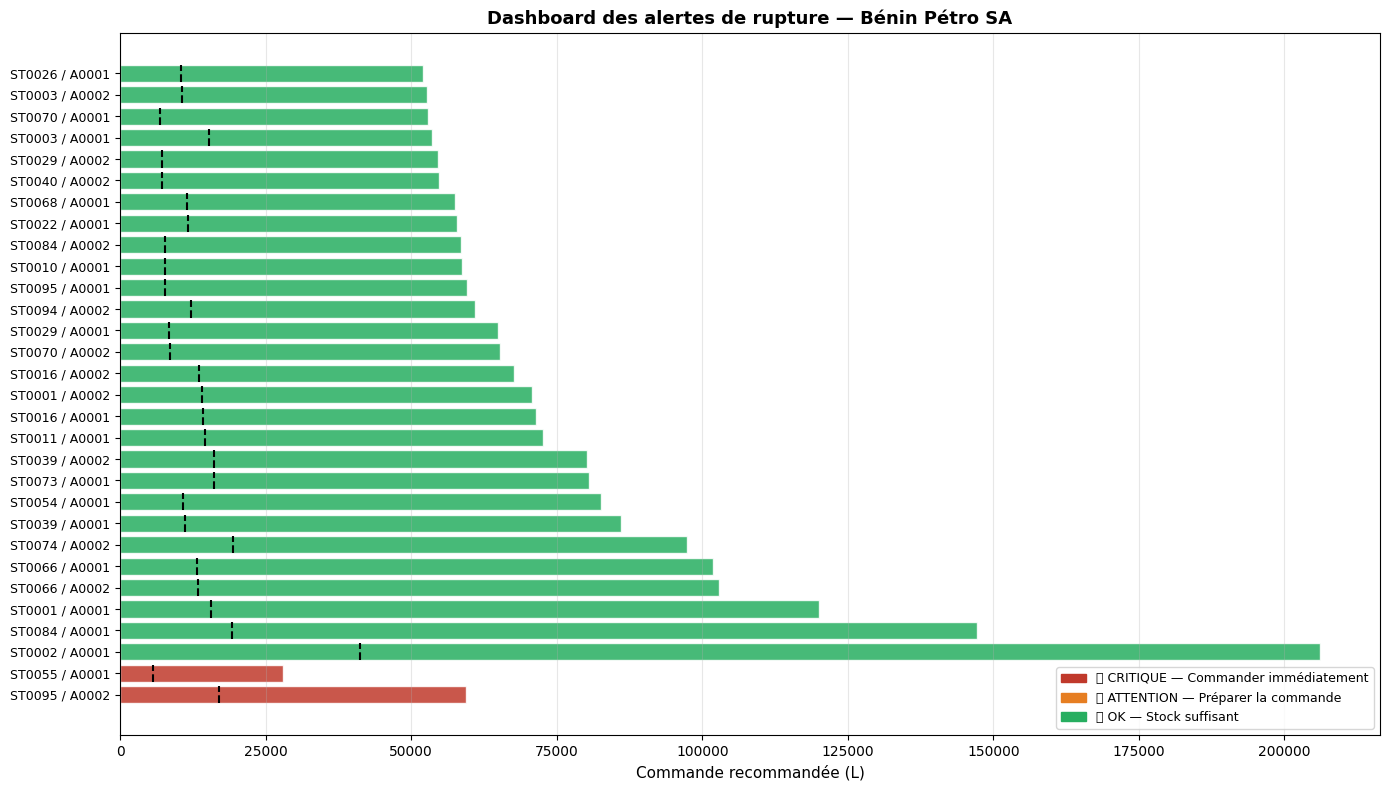

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# GRAPHIQUE 1 — Dashboard des alertes par station
# ══════════════════════════════════════════════════════════════════════════════

couleur_alerte = {
    'CRITIQUE'  : '#C0392B',
    'ATTENTION' : '#E67E22',
    'OK'        : '#27AE60'
}

df_plot = df_commandes.sort_values(
    ['Priorite', 'Commande_totale_L'], ascending=[True, False]
).head(30)   # top 30 stations

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    range(len(df_plot)),
    df_plot['Commande_totale_L'],
    color=[couleur_alerte[n] for n in df_plot['Niveau_alerte']],
    alpha=0.85, edgecolor='white'
)

# Ligne seuil critique
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.plot([row['Seuil_critique_L'], row['Seuil_critique_L']],
            [i - 0.4, i + 0.4], color='black', linewidth=1.5, linestyle='--')

labels = df_plot['Code Station'] + ' / ' + df_plot['N° article']
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Commande recommandée (L)', fontsize=11)
ax.set_title('Dashboard des alertes de rupture — Bénin Pétro SA',
             fontsize=13, fontweight='bold')

# Légende
patches = [
    mpatches.Patch(color='#C0392B', label='🔴 CRITIQUE — Commander immédiatement'),
    mpatches.Patch(color='#E67E22', label='🟠 ATTENTION — Préparer la commande'),
    mpatches.Patch(color='#27AE60', label='🟢 OK — Stock suffisant'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('dashboard_alertes.png', dpi=150, bbox_inches='tight')
plt.show()


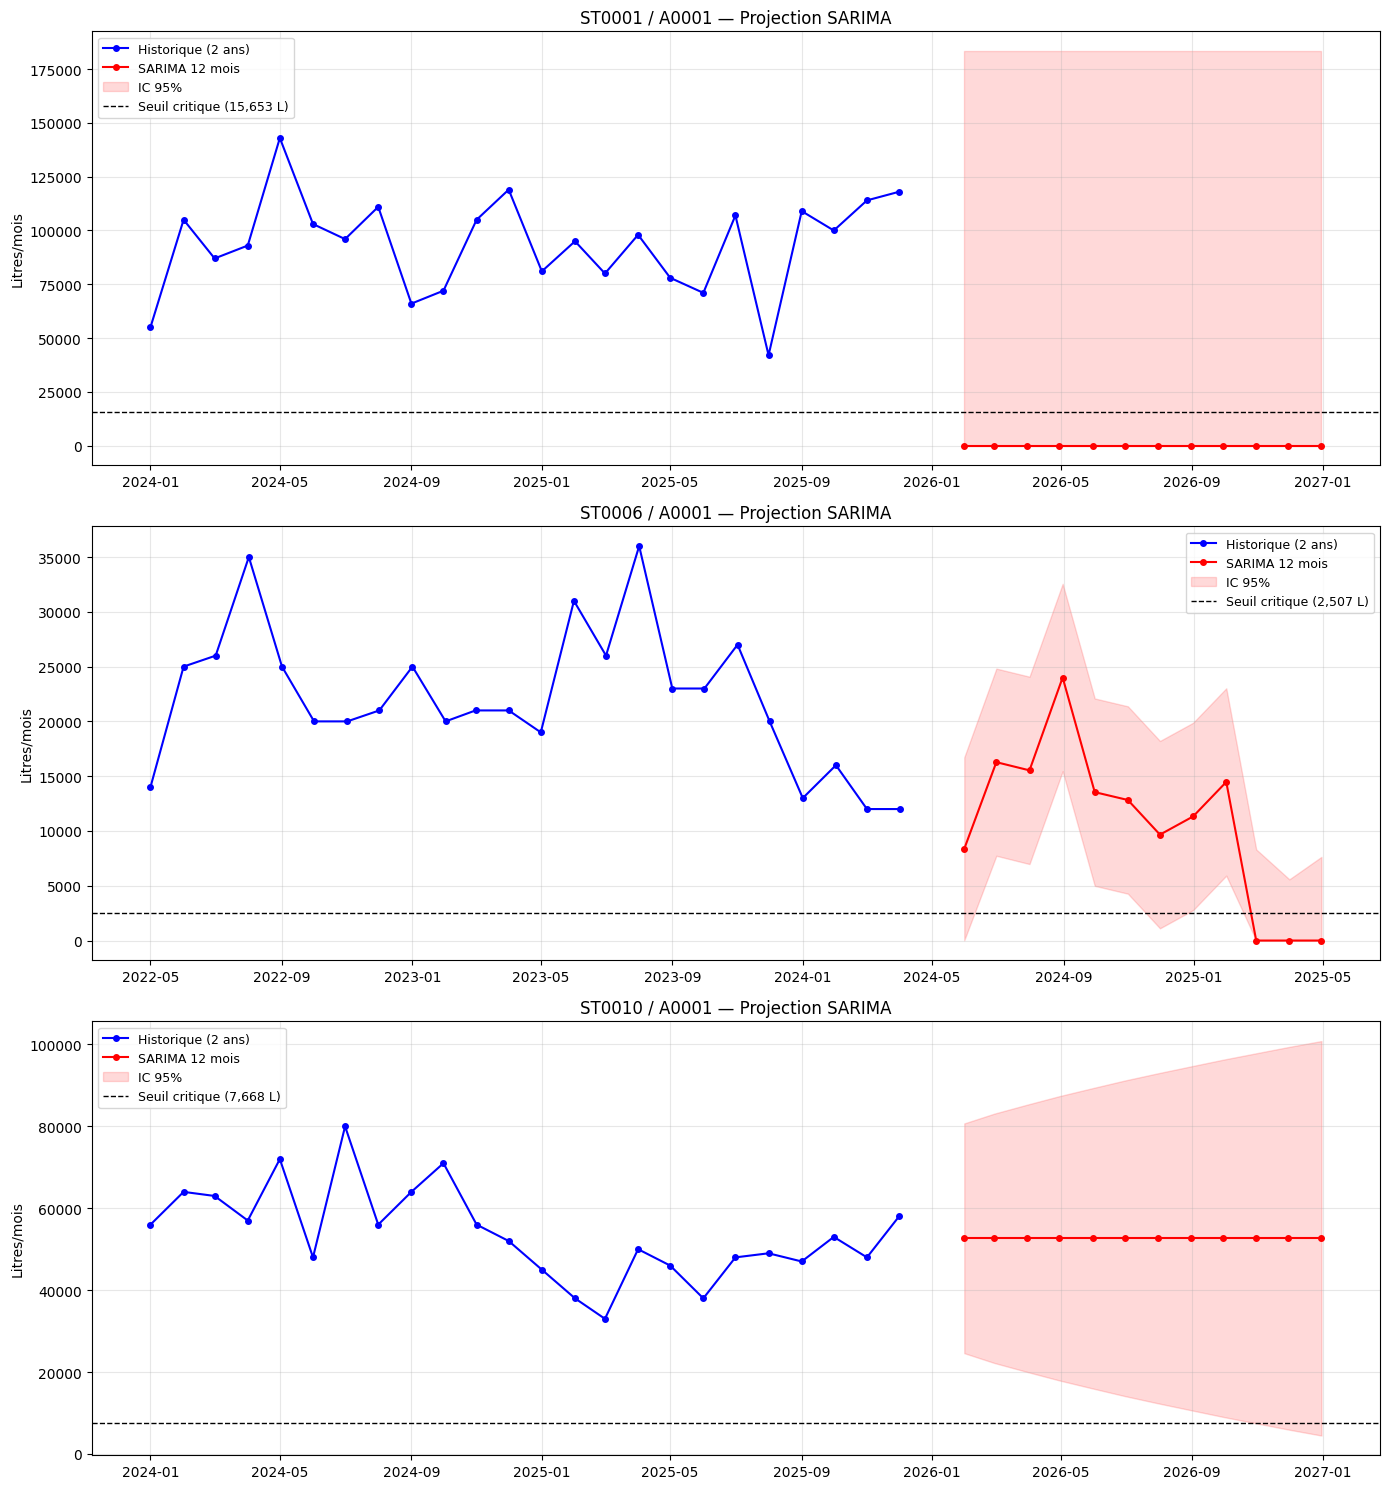

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# GRAPHIQUE 2 — Projections SARIMA + seuils pour stations stables
# ══════════════════════════════════════════════════════════════════════════════

if len(df_sarima) > 0:

    # Prendre les 3 premières stations stables pour l'illustration
    stations_ex = df_sarima['Code Station'].unique()[:3]

    fig, axes = plt.subplots(len(stations_ex), 1,
                              figsize=(14, 5 * len(stations_ex)))
    if len(stations_ex) == 1:
        axes = [axes]

    for ax, station in zip(axes, stations_ex):
        article = df_sarima[df_sarima['Code Station'] == station]['N° article'].iloc[0]
        df_s    = df_sarima[
            (df_sarima['Code Station'] == station) &
            (df_sarima['N° article']   == article)
        ]

        # Historique
        serie_hist = (
            df_ml[
                (df_ml['Code Station'] == station) &
                (df_ml['N° article']   == article)
            ]
            .sort_values('mois')
            .tail(24)
        )

        ax.plot(serie_hist['mois'], serie_hist['quantite_mois'],
                'b-o', label='Historique (2 ans)', markersize=4, linewidth=1.5)

        # Prévisions
        future_x = pd.date_range(
            start=serie_hist['mois'].max() + pd.DateOffset(months=1),
            periods=12, freq='ME'
        )
        ax.plot(future_x, df_s['Prevision_L'],
                'r-o', label='SARIMA 12 mois', markersize=4, linewidth=1.5)
        ax.fill_between(future_x, df_s['IC_bas_L'], df_s['IC_haut_L'],
                        color='red', alpha=0.15, label='IC 95%')

        # Seuil critique
        seuil = df_commandes[
            (df_commandes['Code Station'] == station) &
            (df_commandes['N° article']   == article)
        ]['Seuil_critique_L'].values[0]

        ax.axhline(y=seuil, color='black', linestyle='--', linewidth=1,
                   label=f'Seuil critique ({seuil:,} L)')

        ax.set_title(f'{station} / {article} — Projection SARIMA', fontsize=12)
        ax.set_ylabel('Litres/mois')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('projections_sarima_stables.png', dpi=120, bbox_inches='tight')
    plt.show()


## 7. Export des fichiers pour Power BI

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPORT POUR POWER BI
# Les trois fichiers CSV seront importés directement dans Power BI
# ══════════════════════════════════════════════════════════════════════════════

# 1. Commandes + alertes (table principale Power BI)
df_commandes.to_csv(
    '../data/propre/alertes_rupture.csv',
    index=False, encoding='utf-8-sig'
)
print("✅ alertes_rupture.csv exporté")
print(f"   {len(df_commandes)} stations × produits")
print(f"   Colonnes : {list(df_commandes.columns)}")
print()

# 2. Projections SARIMA (table secondaire Power BI)
if len(df_sarima) > 0:
    df_sarima.to_csv(
        '../data/propre/projections_sarima_12mois.csv',
        index=False, encoding='utf-8-sig'
    )
    print("✅ projections_sarima_12mois.csv exporté")
    print(f"   {len(df_sarima)} lignes ({len(df_sarima)//12} stations × 12 mois)")
    print()

# 3. Résumé des alertes (pour la page d'accueil Power BI)
resume_alertes = (
    df_commandes.groupby('Niveau_alerte')
    .agg(
        Nb_stations            = ('Code Station', 'count'),
        Volume_total_commande_L = ('Commande_totale_L', 'sum'),
    )
    .reset_index()
)
resume_alertes.to_csv(
    '../data/propre/resume_alertes.csv',
    index=False, encoding='utf-8-sig'
)
print("✅ resume_alertes.csv exporté")
print()
print(resume_alertes.to_string(index=False))
print()
print("=" * 55)
print("Ces 3 fichiers sont prêts à être importés dans Power BI.")
print("=" * 55)


✅ alertes_rupture.csv exporté
   171 stations × produits
   Colonnes : ['Code Station', 'N° article', 'Dernier_mois_connu', 'Prevision_mois_suivant_L', 'segment', 'cv', 'vol_moy', 'Stock_securite_L', 'Commande_totale_L', 'Stock_actuel_estime_L', 'Seuil_critique_L', 'Seuil_attention_L', 'Niveau_alerte', 'Priorite']

✅ projections_sarima_12mois.csv exporté
   132 lignes (11 stations × 12 mois)

✅ resume_alertes.csv exporté

Niveau_alerte  Nb_stations  Volume_total_commande_L
     CRITIQUE            2                    87300
           OK          169                  5378588

Ces 3 fichiers sont prêts à être importés dans Power BI.


## 8. Guide d'intégration Power BI

### Étapes d'importation dans Power BI

**Étape 1 — Importer les 3 fichiers CSV**
```
Accueil → Obtenir des données → Texte/CSV
→ alertes_rupture.csv
→ projections_sarima_12mois.csv
→ resume_alertes.csv
```

**Étape 2 — Mesures DAX à créer**
```dax
Stations Critiques =
CALCULATE(COUNTROWS(alertes_rupture),
          alertes_rupture[Niveau_alerte] = "CRITIQUE")

Stations Attention =
CALCULATE(COUNTROWS(alertes_rupture),
          alertes_rupture[Niveau_alerte] = "ATTENTION")

Volume Total Commandes =
SUM(alertes_rupture[Commande_totale_L])

Taux Rupture % =
DIVIDE(
    CALCULATE(COUNTROWS(alertes_rupture),
              alertes_rupture[Niveau_alerte] = "CRITIQUE"),
    COUNTROWS(alertes_rupture)
) * 100
```

**Étape 3 — Visuels recommandés**
```
Page 1 — Vue d'ensemble
  → KPI : nb stations critiques / attention / OK
  → Carte choroplèthe : alertes par région (si coordonnées disponibles)
  → Tableau : top 10 stations à commander en urgence

Page 2 — Détail station
  → Filtre : Code Station + N° article
  → Graphique ligne : historique + projection SARIMA + IC
  → Jauge : stock actuel vs seuil critique

Page 3 — Planification annuelle
  → Courbe SARIMA 12 mois avec IC 95%
  → Histogramme mensuel des volumes prévisionnels
  → Tableau récapitulatif par segment A/B/C
```

**Étape 4 — Actualisation automatique**
```
Planifier l'actualisation mensuelle :
Power BI Service → Jeu de données → Actualisation planifiée
→ Fréquence : mensuelle (1er du mois)
→ Source : fichiers CSV régénérés par ce notebook
```